In [ ]:
import json, os

kaggle_username = "gerardovilcamiza"
kaggle_key = "KGAT_cd51949fce1fcb97005e496f903c345a"

os.makedirs("/root/.kaggle", exist_ok=True)

with open("/root/.kaggle/kaggle.json", "w") as f:
    json.dump({
        "username": kaggle_username,
        "key": kaggle_key
    }, f)

!chmod 600 /root/.kaggle/kaggle.json

In [ ]:
!kaggle datasets download -d tschandl/isic2018-challenge-task1-data-segmentation -p data --unzip

Dataset URL: https://www.kaggle.com/datasets/tschandl/isic2018-challenge-task1-data-segmentation
License(s): CC0-1.0
100% 12.9G/12.9G [01:42<00:00, 134MB/s]



In [ ]:
!pip install -q kaggle albumentations opencv-python matplotlib tqdm

In [ ]:
import os, json, cv2, torch, numpy as np, matplotlib.pyplot as plt
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, random_split
import albumentations as A
from albumentations.pytorch import ToTensorV2
from tqdm import tqdm
import random

device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

In [ ]:
image_dir = "data/ISIC2018_Task1-2_Training_Input"
mask_dir = "data/ISIC2018_Task1_Training_GroundTruth"

images = sorted([f for f in os.listdir(image_dir) if f.endswith(".jpg")])

len(images)

2594

In [ ]:
class ISICDataset(Dataset):
    def __init__(self, image_dir, mask_dir, images, transform=None, subset_ratio=0.1, seed=42):
        self.image_dir = image_dir
        self.mask_dir = mask_dir
        self.transform = transform

        rng = random.Random(seed)
        images = images.copy()
        rng.shuffle(images)

        n = int(len(images) * subset_ratio)
        self.images = images[:n]

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        image_name = self.images[idx]
        mask_name = image_name.replace(".jpg", "_segmentation.png")

        image_path = os.path.join(self.image_dir, image_name)
        mask_path = os.path.join(self.mask_dir, mask_name)

        image = cv2.imread(image_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
        mask = (mask > 127).astype(np.float32)

        if self.transform:
            data = self.transform(image=image, mask=mask)
            image = data["image"]
            mask = data["mask"].unsqueeze(0)

        return image, mask

In [ ]:
train_transform = A.Compose([
    A.Resize(256, 256),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.RandomRotate90(p=0.5),
    A.Normalize(),
    ToTensorV2()
])

val_transform = A.Compose([
    A.Resize(256, 256),
    A.Normalize(),
    ToTensorV2()
])

In [ ]:
full_dataset = ISICDataset(image_dir, mask_dir, images, transform=train_transform, subset_ratio=0.1)

train_size = int(0.8 * len(full_dataset))
val_size = len(full_dataset) - train_size

train_dataset, val_dataset = random_split(full_dataset, [train_size, val_size])

val_dataset.dataset.transform = val_transform

train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=8, shuffle=False, num_workers=2)

In [ ]:
class DoubleConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()

        self.block = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),

            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.block(x)


class UNet(nn.Module):
    def __init__(self, in_channels=3, out_channels=1):
        super().__init__()

        self.enc1 = DoubleConv(in_channels, 64)
        self.enc2 = DoubleConv(64, 128)
        self.enc3 = DoubleConv(128, 256)
        self.enc4 = DoubleConv(256, 512)

        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

        self.bottleneck = DoubleConv(512, 1024)

        self.up4 = nn.ConvTranspose2d(1024, 512, kernel_size=2, stride=2)
        self.dec4 = DoubleConv(1024, 512)

        self.up3 = nn.ConvTranspose2d(512, 256, kernel_size=2, stride=2)
        self.dec3 = DoubleConv(512, 256)

        self.up2 = nn.ConvTranspose2d(256, 128, kernel_size=2, stride=2)
        self.dec2 = DoubleConv(256, 128)

        self.up1 = nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2)
        self.dec1 = DoubleConv(128, 64)

        self.output = nn.Conv2d(64, out_channels, kernel_size=1)

    def forward(self, x):
        s1 = self.enc1(x)
        s2 = self.enc2(self.pool(s1))
        s3 = self.enc3(self.pool(s2))
        s4 = self.enc4(self.pool(s3))

        b = self.bottleneck(self.pool(s4))

        d4 = self.up4(b)
        d4 = torch.cat([d4, s4], dim=1)
        d4 = self.dec4(d4)

        d3 = self.up3(d4)
        d3 = torch.cat([d3, s3], dim=1)
        d3 = self.dec3(d3)

        d2 = self.up2(d3)
        d2 = torch.cat([d2, s2], dim=1)
        d2 = self.dec2(d2)

        d1 = self.up1(d2)
        d1 = torch.cat([d1, s1], dim=1)
        d1 = self.dec1(d1)

        return self.output(d1)

In [ ]:
def dice_score(logits, targets, threshold=0.5, eps=1e-7):
    probs = torch.sigmoid(logits)
    preds = (probs > threshold).float()

    intersection = (preds * targets).sum(dim=(1, 2, 3))
    union = preds.sum(dim=(1, 2, 3)) + targets.sum(dim=(1, 2, 3))

    dice = (2 * intersection + eps) / (union + eps)

    return dice.mean()

In [ ]:
model = UNet().to(device)

criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

In [ ]:
epochs = 20

train_losses = []
val_losses = []
val_dices = []

for epoch in range(epochs):
    model.train()
    total_train_loss = 0

    for images_batch, masks_batch in tqdm(train_loader):
        images_batch = images_batch.to(device)
        masks_batch = masks_batch.to(device)

        logits = model(images_batch)
        loss = criterion(logits, masks_batch)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_train_loss += loss.item()

    model.eval()
    total_val_loss = 0
    total_val_dice = 0

    with torch.no_grad():
        for images_batch, masks_batch in val_loader:
            images_batch = images_batch.to(device)
            masks_batch = masks_batch.to(device)

            logits = model(images_batch)
            loss = criterion(logits, masks_batch)
            dice = dice_score(logits, masks_batch)

            total_val_loss += loss.item()
            total_val_dice += dice.item()

    avg_train_loss = total_train_loss / len(train_loader)
    avg_val_loss = total_val_loss / len(val_loader)
    avg_val_dice = total_val_dice / len(val_loader)

    train_losses.append(avg_train_loss)
    val_losses.append(avg_val_loss)
    val_dices.append(avg_val_dice)

    print(f"Epoch {epoch+1}/{epochs} | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f} | Val Dice: {avg_val_dice:.4f}")

100%|██████████| 26/26 [00:36<00:00,  1.40s/it]


Epoch 1/20 | Train Loss: 0.6588 | Val Loss: 0.6261 | Val Dice: 0.5070


100%|██████████| 26/26 [00:38<00:00,  1.48s/it]


Epoch 2/20 | Train Loss: 0.5244 | Val Loss: 0.5467 | Val Dice: 0.5764


100%|██████████| 26/26 [00:35<00:00,  1.35s/it]


...

Epoch 18/20 | Train Loss: 0.2542 | Val Loss: 0.2783 | Val Dice: 0.7617


100%|██████████| 26/26 [00:33<00:00,  1.29s/it]


Epoch 19/20 | Train Loss: 0.2574 | Val Loss: 0.2693 | Val Dice: 0.7762


100%|██████████| 26/26 [00:33<00:00,  1.28s/it]


Epoch 20/20 | Train Loss: 0.2554 | Val Loss: 0.2872 | Val Dice: 0.7750


In [ ]:
torch.save(model.state_dict(), "unet_isic2018_from_scratch.pth")

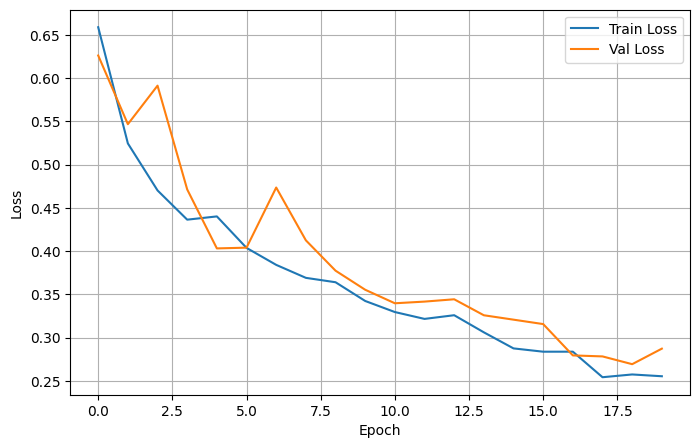

In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid()
plt.show()

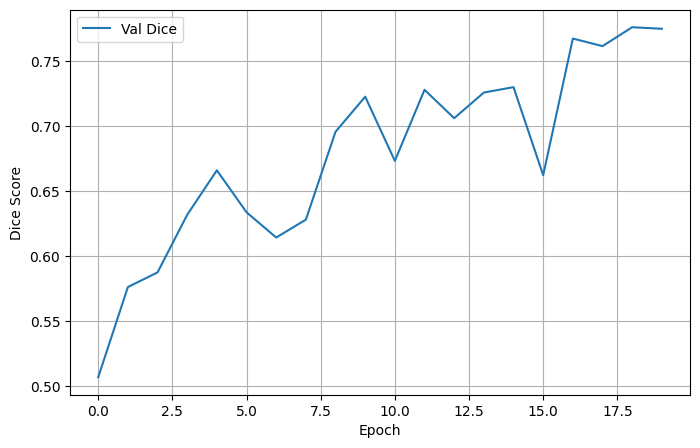

In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(val_dices, label="Val Dice")
plt.xlabel("Epoch")
plt.ylabel("Dice Score")
plt.legend()
plt.grid()
plt.show()

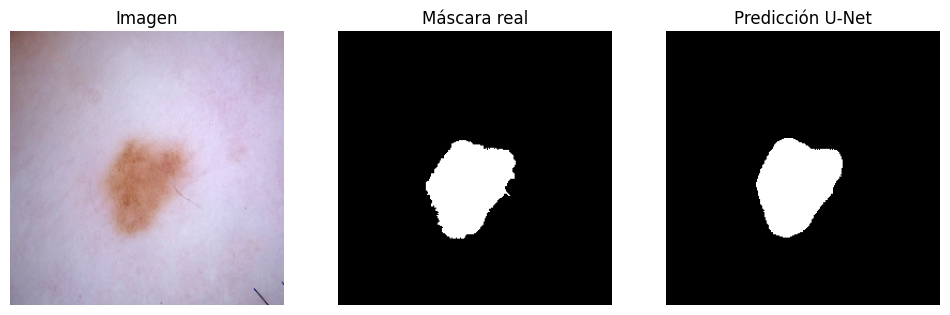

In [ ]:
model.eval()

images_batch, masks_batch = next(iter(val_loader))
images_batch = images_batch.to(device)

with torch.no_grad():
    logits = model(images_batch)
    probs = torch.sigmoid(logits)
    preds = (probs > 0.5).float()

idx = random.randint(0, images_batch.shape[0] - 1)

image = images_batch[idx].cpu().permute(1, 2, 0).numpy()
mask = masks_batch[idx][0].cpu().numpy()
pred = preds[idx][0].cpu().numpy()

image = (image - image.min()) / (image.max() - image.min())

plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.imshow(image)
plt.title("Imagen")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(mask, cmap="gray")
plt.title("Máscara real")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(pred, cmap="gray")
plt.title("Predicción U-Net")
plt.axis("off")

plt.show()